# 파트 1 최종 — 지표면온도 (LST)

2026 부산광역시 빅데이터 활용 경진대회 · 산지도시 부산의 열섬 진단

가이드라인 2-4 **종속변수 3종**을 확정한다.

| 변수 | 산식 | 비고 |
|---|---|---|
| `LST_주간` | Landsat 8/9 C2L2 · `ST_B10×0.00341802+149.0−273.15` | 6~8월 다중시기 중앙값 |
| `LST_야간` | ECOSTRESS L2T (~70m) → 100m 집계 | 여름 야간 · **장면 정규화** |
| **`LST_anomaly`** | `LST − f(표고)`, f = 산림·녹지 픽셀 회귀 | **핵심** |

```
[0]  설정 · 환경          [1]  격자 · 유틸
[2]  야간 원자료 · 인벤토리 [3]  보조레이어 · 육지마스크 · 수변거리
[4]  주간 LST             [5]  야간 LST (모자이크 → 정규화 → 합성)
[6]  LST_anomaly          [7]  행정동 결합
[8]  hex 테이블           [9]  AWS 검증용 스택
[10] 품질 점검            [11] 메타 · 가이드라인 정합성
```

## [0] 설정 · 환경

In [8]:
# pip install earthengine-api geemap earthaccess rasterio h3 scipy pyarrow
#             geopandas shapely matplotlib   (+ cupy-cuda12x 선택)
from pathlib import Path

BASE_DIR  = Path(r"C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트"
                 r"\2026 부산광역시 빅데이터 활용 경진대회\data\part1")  # 2026-08-16: data/지표면 온도 데이터 -> data/part1 개명
BUSAN_SHP = str(BASE_DIR / "행정동" / "BND_ADM_DONG_PG.shp")  # 2026-08-16: data/행정동 -> data/part1/행정동 (part1 전용 입력이라 이 아래로 이동)

RAW_ECO    = str(BASE_DIR / "raw" / "ecostress")
RAW_DAY    = str(BASE_DIR / "raw" / "landsat")
OUT_DIR    = str(BASE_DIR / "processed")
REPORT_DIR = str(BASE_DIR / "reports")
TABLE_DIR  = str(BASE_DIR / "tables")

import os; GCP_PROJECT = os.environ.get("GEE_PROJECT", "your-gcp-project-id")
USE_GPU     = True

# ── 공통 ─────────────────────────────────────────────────────────────
BUSAN_BBOX   = (128.74, 34.85, 129.32, 35.42)     # W,S,E,N EPSG:4326
CRS_ANALYSIS = "EPSG:5186"
TARGET_RES_M = 100
H3_RES       = 10

# ── 주간 (Landsat) ───────────────────────────────────────────────────
DAY_YEARS        = [2021, 2022, 2023, 2024, 2025]
SCENE_CLOUD_MAX  = 80
DAY_MIN_OBS      = 5
EXPORT_RES       = 30
USE_ST_QA_FILTER = False       # 하드필터 미사용
ST_QA_REPORT_K   = 3.0         # 보고 기준 (초과 관측비율 산출)
COLLECTIONS      = ["LANDSAT/LC08/C02/T1_L2", "LANDSAT/LC09/C02/T1_L2"]

# ── 야간 (ECOSTRESS v002) ────────────────────────────────────────────
ECO_YEARS       = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
ECO_LAYERS_KEEP = ("_LST.tif", "_cloud.tif", "_QC.tif", "_water.tif")
QC_ACCEPT       = (0,)         # v002 QC bits1-0 : 0=정상
NIGHT_MIN_COV   = 0.03         # 관측이 덮어야 할 부산 육지 최소 비율
NIGHT_MIN_OBS   = 3            # 픽셀별 최소 유효관측
PLAUSIBLE_C     = (5, 55)
REF_HOUR_KST    = 3.0          # 정규화 기준시각
NORM_MIN_CELLS  = 2000

In [9]:
import os, re, glob, math, json, time, warnings
import numpy as np, pandas as pd, rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, transform_bounds, transform as _tf
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager

for d in (RAW_ECO, RAW_DAY, OUT_DIR, REPORT_DIR, TABLE_DIR):
    os.makedirs(d, exist_ok=True)
warnings.simplefilter("ignore", RuntimeWarning)

# 한글 폰트
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
           "Noto Sans CJK KR"):
    if _f in _avail:
        matplotlib.rc("font", family=_f)
        print("폰트:", _f); break
else:
    print("한글 폰트 없음 — 그림 제목이 깨질 수 있음")
matplotlib.rcParams["axes.unicode_minus"] = False


def get_xp():
    if not USE_GPU:
        return np, False
    try:
        import cupy as cp
        if cp.cuda.runtime.getDeviceCount() == 0:
            raise RuntimeError("no CUDA device")
        d = cp.cuda.runtime.getDeviceProperties(0)
        print("GPU:", d["name"].decode())
        return cp, True
    except Exception as e:
        print("CPU 폴백:", type(e).__name__)
        return np, False

xp, GPU = get_xp()
to_np = (lambda a: xp.asnumpy(a)) if GPU else (lambda a: np.asarray(a))
print("backend:", "cupy(GPU)" if GPU else "numpy(CPU)")
print("BASE_DIR 존재:", BASE_DIR.exists(), "| SHP 존재:", os.path.exists(BUSAN_SHP))

폰트: Malgun Gothic
GPU: NVIDIA GeForce RTX 4060 Ti
backend: cupy(GPU)
BASE_DIR 존재: True | SHP 존재: True


## [1] 공통 격자 · 유틸 — 파트 2·4도 이 규격을 따를 것

In [10]:
_w, _s, _e, _n = BUSAN_BBOX
_l, _b, _r, _t = transform_bounds("EPSG:4326", CRS_ANALYSIS, _w, _s, _e, _n,
                                  densify_pts=21)
R = TARGET_RES_M
LEFT   = math.floor(_l/R)*R;  BOTTOM = math.floor(_b/R)*R
RIGHT  = math.ceil(_r/R)*R;   TOP    = math.ceil(_t/R)*R
WIDTH  = int((RIGHT-LEFT)/R); HEIGHT = int((TOP-BOTTOM)/R)
TRANSFORM = rasterio.transform.from_origin(LEFT, TOP, R, R)
GRID = dict(crs=CRS_ANALYSIS, res=R, width=WIDTH, height=HEIGHT,
            bounds=(LEFT, BOTTOM, RIGHT, TOP))
print(GRID, f"{WIDTH*HEIGHT:,} cells")


def to_grid(a, crs, tr, rs=Resampling.average):
    d = np.full((HEIGHT, WIDTH), np.nan, "float32")
    reproject(source=a, destination=d, src_transform=tr, src_crs=crs,
              dst_transform=TRANSFORM, dst_crs=CRS_ANALYSIS,
              src_nodata=np.nan, dst_nodata=np.nan, resampling=rs)
    return d


def load(p, rs=Resampling.average):
    with rasterio.open(p) as s:
        a = s.read(1).astype("float32")
        if s.nodata is not None and not np.isnan(s.nodata):
            a[a == s.nodata] = np.nan
        if (str(s.crs) == CRS_ANALYSIS and s.width == WIDTH
                and s.height == HEIGHT and abs(s.transform.c-LEFT) < 1):
            return a
        return to_grid(a, s.crs, s.transform, rs)


def write_grid(p, a, dtype="float32", nodata=np.nan):
    with rasterio.open(p, "w", driver="GTiff", height=HEIGHT, width=WIDTH, count=1,
                       dtype=dtype, crs=CRS_ANALYSIS, transform=TRANSFORM,
                       nodata=nodata, compress="deflate", tiled=True) as d:
        d.write(a.astype(dtype), 1)
    print("  saved", os.path.basename(p))


def ols(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 100:
        return np.nan, np.nan, np.nan, int(m.sum())
    b_, a_ = np.polyfit(x[m], y[m], 1)
    return b_, a_, np.corrcoef(x[m], y[m])[0, 1]**2, int(m.sum())


def show(panels, ncol=3, figsize_per=(6, 5.5)):
    n = len(panels); nrow = math.ceil(n/ncol)
    fig, ax = plt.subplots(nrow, min(ncol, n),
                           figsize=(figsize_per[0]*min(ncol, n),
                                    figsize_per[1]*nrow))
    ax = np.atleast_1d(ax).ravel()
    for a_, (t, arr, cm, vr) in zip(ax, panels):
        im = a_.imshow(arr, cmap=cm, **({} if vr is None
                                        else dict(vmin=vr[0], vmax=vr[1])))
        a_.set_title(t); a_.set_xticks([]); a_.set_yticks([])
        plt.colorbar(im, ax=a_, shrink=.75)
    for a_ in ax[n:]:
        a_.axis("off")
    plt.tight_layout(); plt.show()

{'crs': 'EPSG:5186', 'res': 100, 'width': 542, 'height': 644, 'bounds': (358000, 251800, 412200, 316200)} 349,048 cells


## [2] 야간 원자료 확보 · 인벤토리

**ECOSTRESS는 GEE로 못 받는다** — GEE 카탈로그의 `NASA/ECOSTRESS/L2T_LSTE/V2` 는
로스앤젤레스 광역권 타일만 적재돼 있다. LP DAAC 직접 다운로드가 유일한 경로다.

**버전은 v002.** v003(2026-04 배포)이 알고리즘은 낫지만 **부산 2021~2025 granule이 0건**이다.

사전 1회: `~/.netrc` (Windows `%USERPROFILE%\_netrc`)
```
machine urs.earthdata.nasa.gov login <ID> password <PW>
```

In [11]:
import earthaccess
try:
    earthaccess.login(strategy="netrc", persist=True)
except Exception:
    earthaccess.login(strategy="interactive", persist=True)

granules = []
for y in ECO_YEARS:
    r = earthaccess.search_data(short_name="ECO_L2T_LSTE", version="002",
                                temporal=(f"{y}-06-01", f"{y}-08-31"),
                                bounding_box=BUSAN_BBOX, day_night_flag="night")
    print(f"  {y}: {len(r):4d}")
    granules += r
links = sorted({u for g in granules for u in g.data_links()
                if u.endswith(ECO_LAYERS_KEEP)})
have = set(os.listdir(RAW_ECO))
todo = [u for u in links if os.path.basename(u) not in have]
print(f"링크 {len(links)} / 신규 {len(todo)}")
if todo:
    earthaccess.download(todo, RAW_ECO, threads=6)
print("파일", len(os.listdir(RAW_ECO)))

c:\Users\<USER>\anaconda3\envs\py11gpu\Lib\site-packages\earthaccess\results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


  2018:   15
  2019:   64
  2020:   22
  2021:    4
  2022:   11
  2023:   40
  2024:   24
  2025:   68
링크 992 / 신규 992


QUEUEING TASKS | :   0%|          | 0/992 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/992 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/992 [00:00<?, ?it/s]

파일 992


### 재처리본 제거

파일명: `ECOv002_L2T_LSTE_<orbit>_<scene>_<tile>_<UTC>_<build>_<iter>_<layer>.tif`

`(orbit, scene, tile, UTC)` 가 같고 `build`/`iter` 만 다르면 **재처리본**이다.
최신 build만 남긴다. 그리고 `(orbit, scene, UTC)` = **하나의 관측**이며 그 아래 타일이 붙는다.
이후 처리는 타일이 아니라 관측 단위로 한다.

In [12]:
PAT = re.compile(
    r"^ECOv(?P<v>\d{3})_L2T_LSTE_(?P<orbit>\d+)_(?P<scene>\d+)_"
    r"(?P<tile>\w{5})_(?P<dt>\d{8}T\d{6})_(?P<build>\d+)_(?P<iter>\d+)"
    r"_(?P<layer>\w+)\.tif$")

rows = []
for f in sorted(glob.glob(os.path.join(RAW_ECO, "*_LST.tif"))):
    m = PAT.match(os.path.basename(f))
    if not m:
        print("파싱 실패:", os.path.basename(f)); continue
    d = m.groupdict(); s = d["dt"]
    utc = pd.Timestamp(f"{s[:4]}-{s[4:6]}-{s[6:8]}T{s[9:11]}:{s[11:13]}:{s[13:15]}",
                       tz="UTC")
    kst = utc.tz_convert("Asia/Seoul")
    rows.append({"prefix": os.path.basename(f)[:-8],
                 "obs": f"{d['orbit']}_{d['scene']}_{d['dt']}", "tile": d["tile"],
                 "build": int(d["build"]), "iter": int(d["iter"]),
                 "utc": utc, "kst": kst,
                 "kst_hour": kst.hour + kst.minute/60,
                 "year": kst.year, "date": kst.date()})

raw_inv = pd.DataFrame(rows)
inv = (raw_inv.sort_values(["build", "iter"])
       .drop_duplicates(["obs", "tile"], keep="last")
       .sort_values("kst").reset_index(drop=True))
by_obs = inv.groupby("obs")["prefix"].apply(list).to_dict()
obs = (inv.groupby("obs")
       .agg(kst=("kst", "first"), kst_hour=("kst_hour", "first"),
            year=("year", "first"), date=("date", "first"),
            n_tile=("tile", "nunique")).sort_values("kst").reset_index())
print(f"타일파일 {len(raw_inv)} → {len(inv)} (재처리본 {len(raw_inv)-len(inv)} 제외)")
print(f"관측 {len(obs)} / 관측일 {obs['date'].nunique()}")
print(obs.groupby("year").agg(관측=("obs", "count"),
                              관측일=("date", "nunique")).to_string())

타일파일 248 → 212 (재처리본 36 제외)
관측 82 / 관측일 62
      관측  관측일
year         
2018   7    6
2019  19   12
2020   8    7
2021   3    3
2022   3    3
2023   7    6
2024  11    9
2025  24   16


## [3] 보조 레이어 · 육지마스크 · 수변거리

### 육지마스크를 세 겹으로 만드는 이유

**SRTMGL1은 해양이 void-fill 되어 있어 `mask()` 가 1을 반환한다.**
단독으로 쓰면 bbox의 96%를 육지로 판정한다. JRC 상시수면이 해안선을 긋고,
ECOSTRESS `water` 다수결이 남는 오탐(남동 해상)을 걷어낸다.

셋의 고유 기여를 출력해 어느 마스크가 실제로 일하는지 확인한다.

In [13]:
import ee, geemap
try:
    ee.Initialize(project=GCP_PROJECT)
except Exception:
    ee.Authenticate(); ee.Initialize(project=GCP_PROJECT)

AOI  = ee.Geometry.Rectangle(list(BUSAN_BBOX), "EPSG:4326", False)
srtm = ee.Image("USGS/SRTMGL1_003")
wc   = ee.ImageCollection("ESA/WorldCover/v200").first()

aux_img = (srtm.rename("elev").toFloat()
           .addBands(srtm.mask().gt(0).rename("srtm_land").toFloat())
           .addBands(wc.remap([10, 20, 30], [1, 1, 1], 0).rename("green").toFloat())
           .addBands(ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence")
                     .gt(50).unmask(0).rename("inland_water").toFloat()))

_ap = os.path.join(RAW_DAY, "busan_aux_100m.tif")
if not os.path.exists(_ap):
    geemap.download_ee_image(aux_img.clip(AOI), filename=_ap, region=AOI.bounds(),
                             scale=TARGET_RES_M, crs=CRS_ANALYSIS, dtype="float32")
with rasterio.open(_ap) as s:
    bi = {(s.descriptions[i] or f"b{i+1}"): i+1 for i in range(s.count)}
    ELEV      = to_grid(s.read(bi["elev"]).astype("float32"), s.crs, s.transform)
    SRTM_LAND = to_grid(s.read(bi["srtm_land"]).astype("float32"), s.crs,
                        s.transform, Resampling.nearest) > 0.5
    GREEN     = to_grid(s.read(bi["green"]).astype("float32"), s.crs, s.transform)
    INLAND_W  = to_grid(s.read(bi["inland_water"]).astype("float32"), s.crs,
                        s.transform, Resampling.nearest) > 0.5
print(f"elev NaN {np.mean(np.isnan(ELEV)):.1%}  "
      f"← 0%면 SRTM이 해양까지 값을 가짐 (단독 육지마스크 불가)")

elev NaN 0.0%  ← 0%면 SRTM이 해양까지 값을 가짐 (단독 육지마스크 불가)


In [14]:
wv = np.zeros((HEIGHT, WIDTH), "float32"); tv = np.zeros((HEIGHT, WIDTH), "float32")
for i, p in enumerate(inv["prefix"], 1):
    q = os.path.join(RAW_ECO, p + "_water.tif")
    if not os.path.exists(q):
        continue
    with rasterio.open(q) as s:
        a = (s.read(1).astype("uint8") & 1).astype("float32")
        g  = to_grid(a, s.crs, s.transform)
        gm = to_grid(np.ones_like(a), s.crs, s.transform)
    m = ~np.isnan(gm)
    wv[m] += np.nan_to_num(g[m]); tv[m] += gm[m]
    if i % 60 == 0:
        print(f"  water {i}/{len(inv)}")

water_frac = np.where(tv >= 3, wv/np.maximum(tv, 1e-6), np.nan)
ECO_LAND = np.where(np.isnan(water_frac), True, water_frac < 0.5)
LAND = SRTM_LAND & ECO_LAND & (~INLAND_W)
N_LAND = int(LAND.sum())

print(f"\n{'마스크':22s} {'셀':>10s} {'km²':>8s}")
for nm, m in [("SRTM_LAND", SRTM_LAND), ("¬INLAND_W (JRC)", ~INLAND_W),
              ("ECO_LAND", ECO_LAND), ("최종 LAND", LAND)]:
    print(f"{nm:22s} {int(m.sum()):10,} {m.sum()/100:8.0f}")
print("\n각 마스크의 고유 기여 (빼면 최종이 늘어나는 양)")
for nm, m in [("SRTM_LAND", SRTM_LAND), ("¬INLAND_W", ~INLAND_W),
              ("ECO_LAND", ECO_LAND)]:
    w = np.ones((HEIGHT, WIDTH), bool)
    for nm2, m2 in [("SRTM_LAND", SRTM_LAND), ("¬INLAND_W", ~INLAND_W),
                    ("ECO_LAND", ECO_LAND)]:
        if nm2 != nm:
            w &= m2
    print(f"  {nm:14s} +{int(w.sum())-N_LAND:7,} 셀 (+{(w.sum()-N_LAND)/100:.0f} km²)")

for a in (ELEV, GREEN):
    a[~LAND] = np.nan
GREEN_PX = (GREEN > 0.5) & LAND
write_grid(f"{OUT_DIR}/busan_land_100m.tif", LAND.astype("float32"), "uint8", 255)

  water 60/212
  water 120/212
  water 180/212

마스크                             셀      km²
SRTM_LAND                 335,660     3357
¬INLAND_W (JRC)           192,295     1923
ECO_LAND                  175,875     1759
최종 LAND                   166,113     1661

각 마스크의 고유 기여 (빼면 최종이 늘어나는 양)
  SRTM_LAND      +  5,388 셀 (+54 km²)
  ¬INLAND_W      +  4,374 셀 (+44 km²)
  ECO_LAND       + 12,794 셀 (+128 km²)
  saved busan_land_100m.tif


In [15]:
from scipy.ndimage import distance_transform_edt
DIST_W = (distance_transform_edt(LAND) * R).astype("float32")
DIST_W[~LAND] = np.nan
write_grid(f"{OUT_DIR}/busan_dist_water_100m.tif", DIST_W)
print(f"수변거리 0~{np.nanmax(DIST_W)/1000:.1f} km | 중앙 {np.nanmedian(DIST_W)/1000:.2f} km")
print("※ 가이드라인 변수표의 '수변거리'는 파트4(토지피복 기반) 소관 — 정의 조율 필요")

  saved busan_dist_water_100m.tif
수변거리 0~5.3 km | 중앙 1.33 km
※ 가이드라인 변수표의 '수변거리'는 파트4(토지피복 기반) 소관 — 정의 조율 필요


## [4] 주간 LST — Landsat 8/9

### `ST_QA` 하드필터를 쓰지 않는다

단계별 관측 수 (부산 육지 중앙값):

| 단계 | 관측수 | `<5`인 육지셀 |
|---|---|---|
| 씬 커버 | 77 | 0.0% |
| + QA_PIXEL | 40 | 3.8% |
| + `ST_QA ≤ 3K` | **10** | **23.9%** |

결측 셀조차 구름 없는 관측이 23회 있는데 이 필터를 걸면 0회가 된다.
`ST_QA` 는 LST 불확실도이고 **여름 부산처럼 대기 수증기가 많은 해안 지역은 원래 크다**
(중앙 3.68K, 3K 초과 관측 72%). 게다가 40회 중앙값 합성에서는 불확실도 큰 픽셀이
자동으로 밀려나므로 사전에 자를 이유가 없다.

→ 필터 없이 합성하고 **불확실도는 별도 레이어로 보고**한다.
비교용으로 필터 적용본도 함께 만들어 [10]에서 공간 편향을 검증한다.

In [16]:
LAND_EE = srtm.mask().gt(0).And(
    ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence")
    .gt(50).unmask(0).Not())

col = None
for cid in COLLECTIONS:
    x = (ee.ImageCollection(cid).filterBounds(AOI)
         .filter(ee.Filter.calendarRange(6, 8, "month"))
         .filter(ee.Filter.calendarRange(min(DAY_YEARS), max(DAY_YEARS), "year"))
         .filter(ee.Filter.lt("CLOUD_COVER", SCENE_CLOUD_MAX)))
    col = x if col is None else col.merge(x)
print(f"cloud<{SCENE_CLOUD_MAX}% 씬 {col.size().getInfo()}장")


def _bit(qa, b):
    return qa.rightShift(b).bitwiseAnd(1)


def prep(img, stqa_filter):
    qa = img.select("QA_PIXEL")
    clear = (_bit(qa, 0).eq(0).And(_bit(qa, 1).eq(0)).And(_bit(qa, 2).eq(0))
             .And(_bit(qa, 3).eq(0)).And(_bit(qa, 4).eq(0)).And(_bit(qa, 5).eq(0)))
    m = clear.And(img.select("ST_B10").gt(0))
    stq = img.select("ST_QA").multiply(0.01).rename("ST_QA_K")
    if stqa_filter:
        m = m.And(stq.lte(ST_QA_REPORT_K))
    lst = (img.select("ST_B10").multiply(0.00341802).add(149.0).subtract(273.15)
           .rename("LST"))
    return (lst.addBands(stq).addBands(stq.gt(ST_QA_REPORT_K).rename("stq_hi"))
            .updateMask(m))


pc   = col.map(lambda im: prep(im, False))
pcf  = col.map(lambda im: prep(im, True))
nobs_ee = pc.select("LST").count().rename("nobs").toInt16()
fin  = lambda im: im.updateMask(nobs_ee.gte(DAY_MIN_OBS)).updateMask(LAND_EE)

day_med_ee   = fin(pc.select("LST").median().rename("LST_day_median"))
day_p90_ee   = fin(pc.select("LST").reduce(ee.Reducer.percentile([90]))
                   .rename("LST_day_p90"))
stqa_med_ee  = fin(pc.select("ST_QA_K").median().rename("ST_QA_median_K"))
stqa_hi_ee   = fin(pc.select("stq_hi").mean().rename("ST_QA_gt3K_frac"))
day_med_f_ee = fin(pcf.select("LST").median().rename("LST_day_median_stqa3"))
print("검산 DN 44947 →", round(44947*0.00341802 + 149.0 - 273.15, 2), "°C")

cloud<80% 씬 77장
검산 DN 44947 → 29.48 °C


In [17]:
tag = f"{min(DAY_YEARS)}_{max(DAY_YEARS)}"
FILES = {f"busan_lst_day_median_{tag}.tif":      (day_med_ee,   EXPORT_RES),
         f"busan_lst_day_p90_{tag}.tif":         (day_p90_ee,   EXPORT_RES),
         f"busan_lst_day_nobs_{tag}.tif":        (nobs_ee,      EXPORT_RES),
         f"busan_day_stqa_median_{tag}.tif":     (stqa_med_ee,  TARGET_RES_M),
         f"busan_day_stqa_gt3K_frac_{tag}.tif":  (stqa_hi_ee,   TARGET_RES_M),
         f"busan_lst_day_median_stqa3_{tag}.tif":(day_med_f_ee, TARGET_RES_M)}
for fn, (img, sc) in FILES.items():
    p = os.path.join(RAW_DAY, fn)
    if os.path.exists(p):
        print("skip", fn); continue
    geemap.download_ee_image(img.clip(AOI), filename=p, region=AOI.bounds(),
                             scale=sc, crs=CRS_ANALYSIS, dtype="float32")
    print("saved", fn)

kf = list(FILES)
day_med   = load(os.path.join(RAW_DAY, kf[0]))
day_p90   = load(os.path.join(RAW_DAY, kf[1]))
day_nobs  = load(os.path.join(RAW_DAY, kf[2]))
stqa_med  = load(os.path.join(RAW_DAY, kf[3]))
stqa_hi   = load(os.path.join(RAW_DAY, kf[4]))
day_med_f = load(os.path.join(RAW_DAY, kf[5]))
for a in (day_med, day_p90, day_nobs, stqa_med, stqa_hi, day_med_f):
    a[~LAND] = np.nan

print(f"\n주간 육지 커버리지 {np.mean(np.isfinite(day_med[LAND])):.1%}"
      f"  (ST_QA 필터 시 {np.mean(np.isfinite(day_med_f[LAND])):.1%})")
print(f"  nobs 중앙 {np.nanmedian(day_nobs[LAND]):.0f}회")
print(f"  ST_QA 중앙 {np.nanmedian(stqa_med[LAND]):.2f} K "
      f"| >3K 관측비율 중앙 {np.nanmedian(stqa_hi[LAND]):.1%}")
for nm, arr in [("median", day_med), ("p90", day_p90), ("nobs", day_nobs),
                ("stqa_median", stqa_med), ("stqa_gt3K_frac", stqa_hi)]:
    write_grid(f"{OUT_DIR}/busan_lst_day_{nm}_100m.tif"
               if nm in ("median", "p90", "nobs")
               else f"{OUT_DIR}/busan_day_{nm}_100m.tif", arr)

c:\Users\<USER>\anaconda3\envs\py11gpu\Lib\site-packages\geemap\common.py:12263: FutureWarning: 'BaseImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  img = gd.download.BaseImage(image)


  0%|          |0/5 tiles [00:00<?]

saved busan_lst_day_median_2021_2025.tif


  0%|          |0/5 tiles [00:00<?]

saved busan_lst_day_p90_2021_2025.tif


...

saved busan_day_stqa_median_2021_2025.tif


  0%|          |0/1 tiles [00:00<?]

saved busan_day_stqa_gt3K_frac_2021_2025.tif


  0%|          |0/1 tiles [00:00<?]

saved busan_lst_day_median_stqa3_2021_2025.tif

주간 육지 커버리지 97.0%  (ST_QA 필터 시 87.9%)
  nobs 중앙 41회
  ST_QA 중앙 3.68 K | >3K 관측비율 중앙 71.7%
  saved busan_lst_day_median_100m.tif
  saved busan_lst_day_p90_100m.tif
  saved busan_lst_day_nobs_100m.tif
  saved busan_day_stqa_median_100m.tif
  saved busan_day_stqa_gt3K_frac_100m.tif


## [5] 야간 LST — 모자이크 → 장면 정규화 → 합성

### 관측 단위 모자이크

한 관측이 여러 MGRS 타일로 쪼개져 있다. 타일별로 커버리지를 재면 109.8 km 타일 전체가
분모가 되어 의미가 없다. **관측 단위로 부산 격자 위에서 합친 뒤** 육지 커버리지를 잰다.

In [18]:
def lst_to_celsius(path):
    """LST COG를 °C로. uint16 DN / float32 K / float32 °C 를 자동 판별."""
    with rasterio.open(path) as s:
        a = s.read(1).astype("float32")
        sc = (s.scales[0] if s.scales else 1.0) or 1.0
        off = (s.offsets[0] if s.offsets else 0.0) or 0.0
        nod, crs, tr = s.nodata, s.crs, s.transform
    if nod is not None and not np.isnan(nod):
        a[a == nod] = np.nan
    if sc != 1.0 or off != 0.0:
        a = a*sc + off
    f_ = a[np.isfinite(a) & (a != 0)]
    m = np.median(f_) if f_.size else np.nan
    if not np.isfinite(m):
        return a*np.nan, crs, tr
    if m > 1000:
        return a*0.02 - 273.15, crs, tr      # 스케일 미적용 DN
    if m > 150:
        return a - 273.15, crs, tr           # 켈빈
    return a, crs, tr                        # 이미 섭씨


def read_tile(prefix):
    lst, crs, tr = lst_to_celsius(os.path.join(RAW_ECO, prefix + "_LST.tif"))
    valid = np.isfinite(lst)

    def aux(sfx):
        q = os.path.join(RAW_ECO, prefix + sfx)
        if not os.path.exists(q):
            return None
        with rasterio.open(q) as s:
            return s.read(1)
    qc = aux("_QC.tif")
    if qc is not None:
        valid &= np.isin(qc.astype("uint16") & 0b11, QC_ACCEPT)
    cl = aux("_cloud.tif")           # v002 QC에는 구름 정보가 없다 (LP DAAC 2024-09 공지)
    if cl is not None:
        valid &= ((cl.astype("uint8") & 1) == 0)
    wa = aux("_water.tif")
    if wa is not None:
        valid &= ((wa.astype("uint8") & 1) == 0)
    lo, hi = PLAUSIBLE_C
    valid &= (lst > lo) & (lst < hi)
    return np.where(valid, lst, np.nan).astype("float32"), crs, tr


layers, cov = {}, []
t0 = time.perf_counter()
for i, o in enumerate(obs["obs"], 1):
    acc = np.full((HEIGHT, WIDTH), np.nan, "float32")
    cnt = np.zeros((HEIGHT, WIDTH), "int16")
    for p in by_obs[o]:
        g = to_grid(*read_tile(p))
        m = ~np.isnan(g)
        acc[m] = np.where(cnt[m] > 0, (acc[m]*cnt[m] + g[m])/(cnt[m]+1), g[m])
        cnt[m] += 1
    acc[~LAND] = np.nan
    f_ = float(np.sum(~np.isnan(acc))/N_LAND)
    cov.append(f_)
    if f_ >= NIGHT_MIN_COV:
        layers[o] = acc
    if i % 20 == 0 or i == len(obs):
        print(f"  {i}/{len(obs)} ({time.perf_counter()-t0:.0f}s)")

obs["cov"] = cov
obs["used"] = obs["cov"] >= NIGHT_MIN_COV
print(f"\n채택 {obs['used'].sum()}/{len(obs)} | 관측일 {obs[obs.used]['date'].nunique()}일")
print(obs[obs.used].groupby("year")
      .agg(관측=("obs", "count"), 관측일=("date", "nunique")).to_string())

  20/82 (7s)
  40/82 (13s)
  60/82 (20s)
  80/82 (28s)
  82/82 (28s)

채택 30/82 | 관측일 28일
      관측  관측일
year         
2018   3    3
2019   4    4
2020   2    2
2022   2    2
2023   3    3
2024   3    3
2025  13   11


### 장면 정규화 ★

ECOSTRESS는 비태양동기궤도라 통과 시각이 KST 19시~6시로 흩어진다.
관측된 냉각폭이 **하룻밤 약 6.5 °C**(0시 23.4 → 5시 16.9)이므로, 보정 없이 중앙값을 내면
*어떤 셀은 이른 시각 장면으로, 옆 셀은 늦은 시각 장면으로* 계산돼
**물리적 이유 없는 공간 경사**가 생긴다.

```
LST(i,c) ≈ a(c) + b(i)     a = 셀 효과(공간패턴), b = 장면 오프셋
```

교대 반복으로 `a`, `b` 를 추정하고 `b` 를 제거한다. 커버리지가 제각각이어도 안정적으로 풀린다.

**시각창으로 장면을 버릴 필요가 없어져 채택 관측 전부를 쓴다.**
오프셋의 시각 설명력은 R²≈0.07 수준이고 나머지는 날씨·계절이므로,
엄밀히는 '시각 정규화'가 아니라 **장면 정규화**다. 날씨 변동까지 제거되어
기후학적 공간패턴 추출에는 오히려 유리하다.

cube (30, 644, 542) 42 MB
수렴 6회 | 장면 오프셋 -6.21 ~ +8.33 °C
냉각률 -0.316 °C/시간 (R²=0.074)
검증 — 장면평균~시각 R² 0.074 → 0.0003 (0에 가까우면 성공)


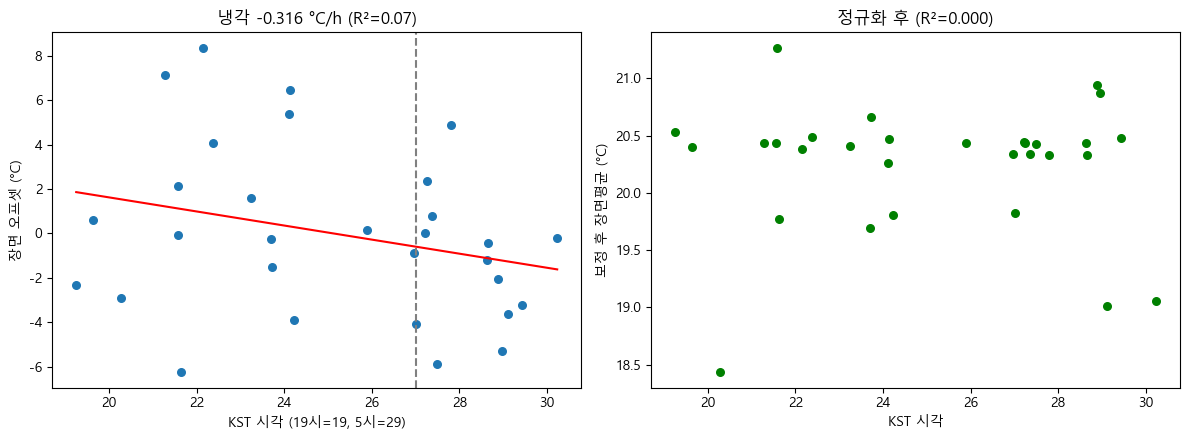

In [19]:
use_ids = list(obs[obs.used]["obs"])
cube  = np.stack([layers[o] for o in use_ids])
hours = obs.set_index("obs").loc[use_ids, "kst_hour"].to_numpy()
valid = np.isfinite(cube)
print(f"cube {cube.shape} {cube.nbytes/1e6:.0f} MB")

b = np.zeros(len(use_ids))
for it in range(30):
    a_c = np.nanmean(cube - b[:, None, None], axis=0)
    resid = cube - a_c[None, :, :]
    nb = np.array([np.nanmean(resid[i][valid[i]])
                   if valid[i].sum() >= NORM_MIN_CELLS else np.nan
                   for i in range(len(use_ids))])
    nb = np.where(np.isfinite(nb), nb, b)
    nb -= np.nanmean(nb)
    if np.max(np.abs(nb - b)) < 1e-4:
        b = nb; break
    b = nb
print(f"수렴 {it+1}회 | 장면 오프셋 {b.min():+.2f} ~ {b.max():+.2f} °C")

h = np.where(hours < 12, hours + 24, hours)
okh = np.isfinite(b) & np.isfinite(h)
p_ = np.polyfit(h[okh], b[okh], 1)
r2_before = np.corrcoef(h[okh], b[okh])[0, 1]**2
href = REF_HOUR_KST + 24 if REF_HOUR_KST < 12 else REF_HOUR_KST
adj = (cube - b[:, None, None] + np.polyval(p_, href)).astype("float32")
chk = np.array([np.nanmean(adj[i]) for i in range(len(use_ids))])
r2_after = np.corrcoef(h[okh], chk[okh])[0, 1]**2
print(f"냉각률 {p_[0]:+.3f} °C/시간 (R²={r2_before:.3f})")
print(f"검증 — 장면평균~시각 R² {r2_before:.3f} → {r2_after:.4f} (0에 가까우면 성공)")

pd.DataFrame({"obs": use_ids, "kst_hour": hours, "offset": b,
              "mean_after": chk}).to_csv(
    f"{REPORT_DIR}/ecostress_scene_offset.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(h, b, s=30)
xs = np.linspace(h.min(), h.max(), 50)
ax[0].plot(xs, np.polyval(p_, xs), "r-"); ax[0].axvline(href, ls="--", c="gray")
ax[0].set_xlabel("KST 시각 (19시=19, 5시=29)"); ax[0].set_ylabel("장면 오프셋 (°C)")
ax[0].set_title(f"냉각 {p_[0]:+.3f} °C/h (R²={r2_before:.2f})")
ax[1].scatter(h, chk, s=30, c="green")
ax[1].set_xlabel("KST 시각"); ax[1].set_ylabel("보정 후 장면평균 (°C)")
ax[1].set_title(f"정규화 후 (R²={r2_after:.3f})")
plt.tight_layout(); plt.show()

In [20]:
def composite(cu):
    t, H, W = cu.shape
    chunk = H
    if GPU:
        free, _ = xp.cuda.runtime.memGetInfo()
        chunk = max(1, min(H, int((free/3)/(t*W*4))))
    nobs = np.empty((H, W), "int16"); med = np.empty((H, W), "float32")
    p10 = np.empty((H, W), "float32")
    hp = hasattr(xp, "nanpercentile")
    for i in range(0, H, chunk):
        j = min(i+chunk, H)
        blk = xp.asarray(cu[:, i:j, :])
        nobs[i:j] = to_np(xp.sum(~xp.isnan(blk), axis=0)).astype("int16")
        med[i:j]  = to_np(xp.nanmedian(blk, axis=0)).astype("float32")
        p10[i:j]  = (to_np(xp.nanpercentile(blk, 10, axis=0)).astype("float32")
                     if hp else np.nanpercentile(cu[:, i:j, :], 10, axis=0))
        del blk
        if GPU:
            xp.get_default_memory_pool().free_all_blocks()
    return nobs, med, p10


t0 = time.perf_counter()
night_nobs, night_med, night_p10 = composite(adj)
thin = night_nobs < NIGHT_MIN_OBS
night_med[thin] = np.nan; night_p10[thin] = np.nan
night_med[~LAND] = np.nan; night_p10[~LAND] = np.nan
print(f"{'GPU' if GPU else 'CPU'} 합성 {time.perf_counter()-t0:.1f}s ({len(use_ids)}관측)")
print(f"육지 커버리지 {np.mean(np.isfinite(night_med[LAND])):.1%}")
print(f"min {np.nanmin(night_med):.1f} | med {np.nanmedian(night_med):.1f} | "
      f"max {np.nanmax(night_med):.1f} °C  (기준 {REF_HOUR_KST:.0f}시 환산)")
print("※ 육지 정의에 ECOSTRESS water 마스크가 들어가므로 100%는 일부 정의상 값")
write_grid(f"{OUT_DIR}/busan_lst_night_median_100m.tif", night_med)
write_grid(f"{OUT_DIR}/busan_lst_night_p10_100m.tif", night_p10)
write_grid(f"{OUT_DIR}/busan_lst_night_nobs_100m.tif",
           night_nobs.astype("float32"), "int16", 0)

GPU 합성 5.8s (30관측)
육지 커버리지 100.0%
min 15.2 | med 20.4 | max 24.4 °C  (기준 3시 환산)
※ 육지 정의에 ECOSTRESS water 마스크가 들어가므로 100%는 일부 정의상 값
  saved busan_lst_night_median_100m.tif
  saved busan_lst_night_p10_100m.tif
  saved busan_lst_night_nobs_100m.tif


## [6] `LST_anomaly` — 가이드라인 핵심 변수

```
LST_anomaly = LST − f(표고),   f = 산림·녹지 픽셀의 LST ~ 표고 회귀
```

**표고는 SRTM 30m로 확정한다.** detrending은 100m에서 전역 기울기 하나를 추정하는
회귀라 SRTM 집계값과 국토지리정보원 5m 집계값이 이 목적에서는 사실상 같다.
정밀 DEM이 필요한 건 미분 기반인 **경사·TPI·향**(파트 2)이다.

녹지 마스크는 ESA WorldCover v200. 파트 4의 환경부 토지피복이 오면
**감률 민감도만 확인**하면 된다.

LST  lapse_C_per_100m  intercept     r2      n
 야간           -0.4961    21.0400 0.5666 106456
 주간           -1.3678    34.3227 0.4621 104239

야간 anomaly p1~p99 -1.4 ~ +2.3 °C
  saved busan_lst_night_anomaly_100m.tif
  saved busan_lst_day_anomaly_100m.tif


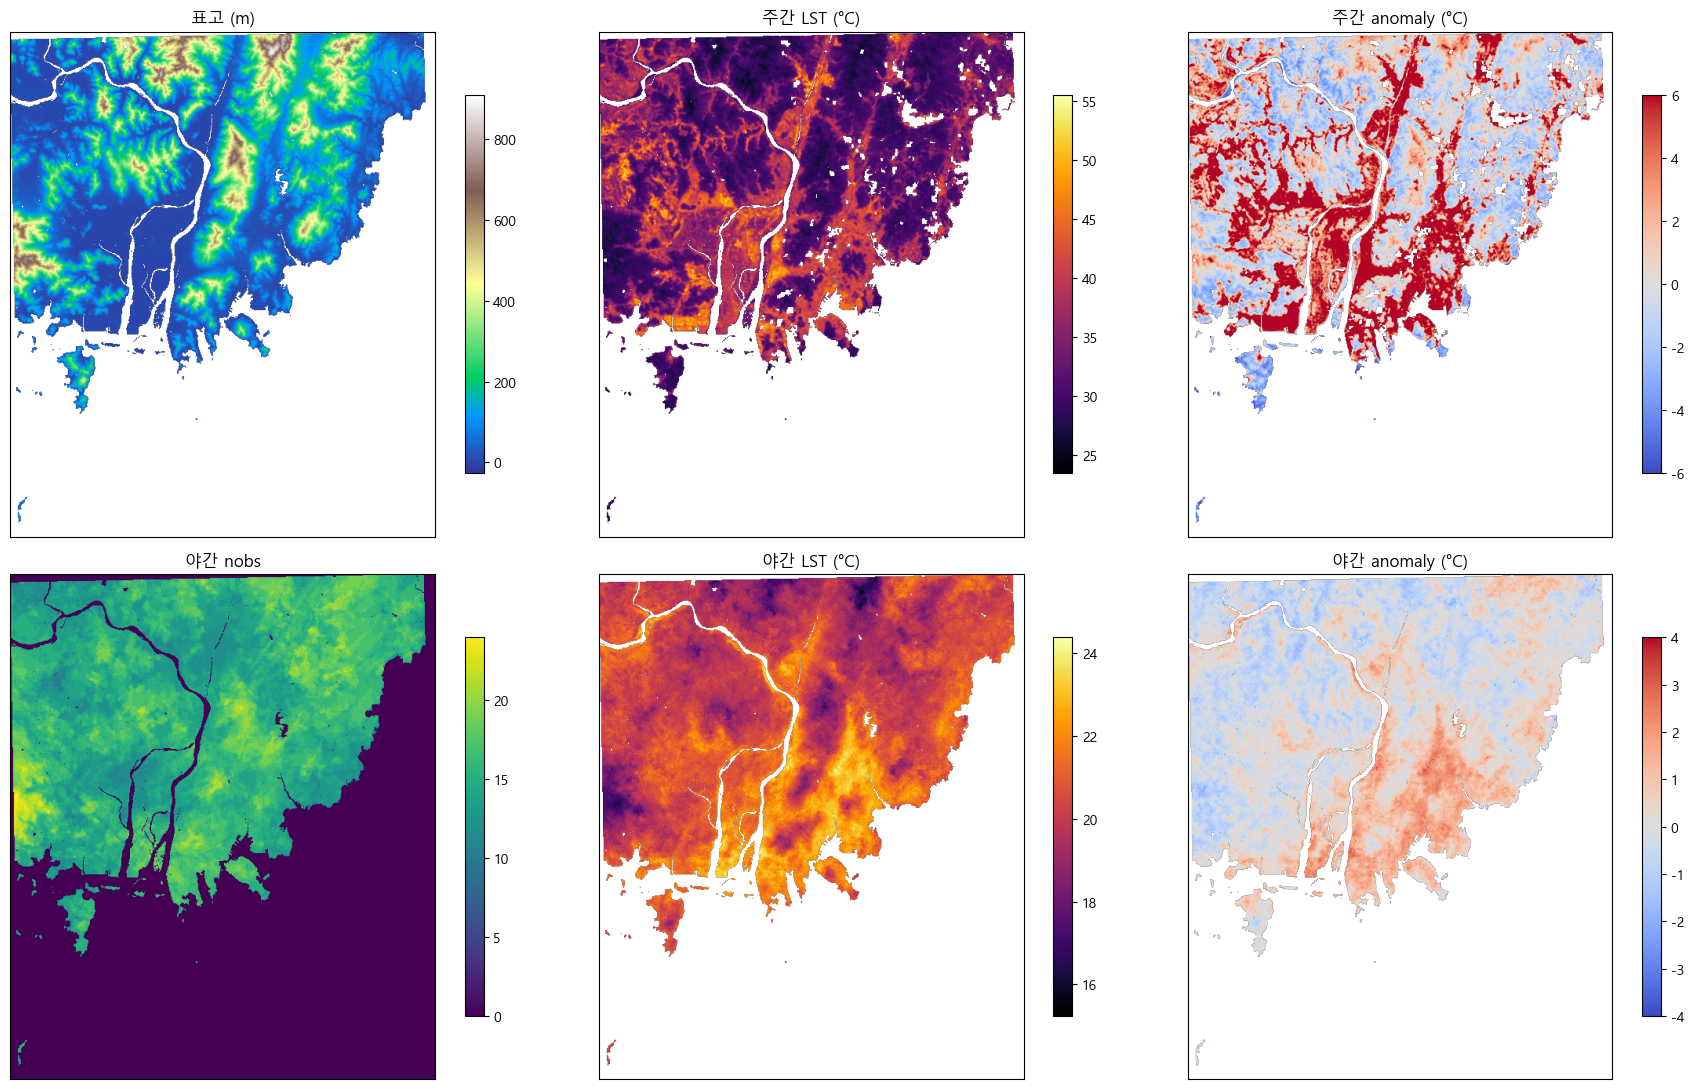

In [21]:
def make_anomaly(lst, elev, gm):
    b_, a_, r2, n = ols(np.where(gm, elev, np.nan), np.where(gm, lst, np.nan))
    return lst - (a_ + b_*elev), dict(lapse_C_per_100m=b_*100, intercept=a_,
                                      r2=r2, n=n)


anom_night, mn_ = make_anomaly(night_med, ELEV, GREEN_PX)
anom_day,   md_ = make_anomaly(day_med,   ELEV, GREEN_PX)
anom_night[~LAND] = np.nan; anom_day[~LAND] = np.nan
print(pd.DataFrame([{"LST": "야간", **mn_}, {"LST": "주간", **md_}])
      .round(4).to_string(index=False))
print(f"\n야간 anomaly p1~p99 {np.nanpercentile(anom_night,1):+.1f} ~ "
      f"{np.nanpercentile(anom_night,99):+.1f} °C")
write_grid(f"{OUT_DIR}/busan_lst_night_anomaly_100m.tif", anom_night)
write_grid(f"{OUT_DIR}/busan_lst_day_anomaly_100m.tif", anom_day)

show([("표고 (m)", ELEV, "terrain", None),
      ("주간 LST (°C)", day_med, "inferno", None),
      ("주간 anomaly (°C)", anom_day, "coolwarm", (-6, 6)),
      ("야간 nobs", night_nobs.astype("float32"), "viridis", None),
      ("야간 LST (°C)", night_med, "inferno", None),
      ("야간 anomaly (°C)", anom_night, "coolwarm", (-4, 4))])

## [7] 행정동 결합

가이드라인 2-3이 *"1차 전역(약 **7만 셀**)"* 이라고 규모를 못박았다.
행정경계로 **클립하지 않고** `in_busan` 플래그만 붙인다 — LISA·GWR 가장자리 추정용 완충대 유지.

행정동 코드도 함께 넣는다. 가이드라인이 여러 곳에서 쓴다.
- 1-2 비교 대상 — *"서울시 423개 **행정동** Hotspot 분석"*
- 2-4 취약변수 — *"온열질환·고령비율·기초수급·독거노인 — 격자/**행정동** 집계"*
- 리스크표 — *"실패 시 야간은 **행정동 단위**로 후퇴"*

### ⚠️ SGIS 코드 함정

`BND_ADM_DONG_PG`(통계청 SGIS)는 **행정표준코드가 아니라 SGIS 자체 코드**를 쓴다.

| | 행정표준코드 | **SGIS** |
|---|---|---|
| 부산 | 26 | **21** |
| 울산 | 31 | **26** |

`ADM_CD[:2] == "26"` 으로 거르면 **울산이 잡힌다.** 실제로 울산 3개 동이 부산 bbox에
걸쳐 있어 에러 없이 조용히 틀린 결과가 나온다.

→ 코드값을 가정하지 않고 **면적과 시군구 수로 판정**한다.
(부산 785.6 km²/16개, 울산 1,064 km²/5개, 경남 10,567 km²/22개)

행 3,559 | CRS EPSG:5186 | 컬럼 ['BASE_DATE', 'ADM_CD', 'ADM_NM', 'geometry']
  기준일 20250630 | 코드=ADM_CD 명칭=ADM_NM

bbox 교차 시도
  21  면적       786 km²  시군구 16   ← 부산
  26  면적     1,064 km²  시군구  5
  38  면적    10,567 km²  시군구 22
→ 부산 시도코드 = 21  (SGIS 체계)
행정동 206개 | 시군구 16개 | 면적 785.6 km²
격자 내 부산 78,520 셀 | ∩육지 74,163 셀 (742 km²)
hex 예상 약 70,251 셀 (가이드라인 '약 7만')
  saved busan_in_boundary_100m.tif


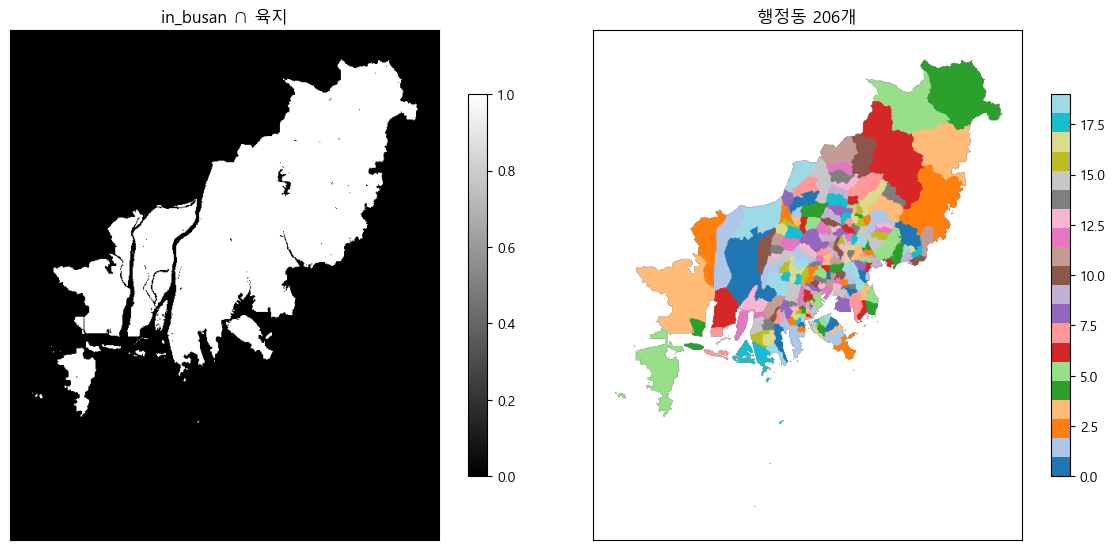

In [22]:
IN_BUSAN = None; ADM_IDX = None; adm_lut = None; SIDO = None
if os.path.exists(BUSAN_SHP):
    import geopandas as gpd
    from rasterio.features import rasterize
    from shapely.geometry import box

    gdf = gpd.read_file(BUSAN_SHP)
    print(f"행 {len(gdf):,} | CRS {gdf.crs} | 컬럼 {list(gdf.columns)}")
    if gdf.crs is None:
        raise SystemExit(".prj 없음 — 좌표계 확인 필요")
    if gdf.crs.to_string() != CRS_ANALYSIS:
        gdf = gdf.to_crs(CRS_ANALYSIS); print(f"  → {CRS_ANALYSIS} 재투영")
    CD = [k for k in gdf.columns if k.upper().endswith("_CD")][0]
    NM = [k for k in gdf.columns if k.upper().endswith("_NM")][0]
    gdf[CD] = gdf[CD].astype(str)
    gdf["sido"] = gdf[CD].str[:2]; gdf["sgg"] = gdf[CD].str[:5]
    if "BASE_DATE" in gdf.columns:
        print(f"  기준일 {gdf['BASE_DATE'].iloc[0]} | 코드={CD} 명칭={NM}")

    near = set(gdf[gdf.intersects(box(LEFT, BOTTOM, RIGHT, TOP))]["sido"])
    ar = gdf.dissolve("sido").geometry.area/1e6
    sg = gdf.groupby("sido")["sgg"].nunique()
    print("\nbbox 교차 시도")
    for s_ in sorted(near):
        hit = 600 < ar[s_] < 950 and sg[s_] >= 10
        print(f"  {s_}  면적 {ar[s_]:9,.0f} km²  시군구 {sg[s_]:2d}"
              + ("   ← 부산" if hit else ""))
    cand = [s_ for s_ in near if 600 < ar[s_] < 950 and sg[s_] >= 10]
    if len(cand) != 1:
        raise SystemExit(f"부산 판정 실패: {cand}")
    SIDO = cand[0]
    print(f"→ 부산 시도코드 = {SIDO}"
          + ("  (SGIS 체계)" if SIDO != "26" else ""))

    bs = gdf[gdf["sido"] == SIDO].copy().reset_index(drop=True)
    print(f"행정동 {len(bs)}개 | 시군구 {bs['sgg'].nunique()}개 "
          f"| 면적 {bs.geometry.area.sum()/1e6:,.1f} km²")

    IN_BUSAN = rasterize([(g_, 1) for g_ in bs.geometry], out_shape=(HEIGHT, WIDTH),
                         transform=TRANSFORM, fill=0, dtype="uint8").astype(bool)
    bs["idx"] = np.arange(1, len(bs)+1)
    ADM_IDX = rasterize([(g_, i) for g_, i in zip(bs.geometry, bs["idx"])],
                        out_shape=(HEIGHT, WIDTH), transform=TRANSFORM,
                        fill=0, dtype="int32").astype("int32")
    adm_lut = bs[["idx", CD, "sgg", NM]].rename(
        columns={CD: "adm_cd", "sgg": "sgg_cd", NM: "adm_nm"})
    n = int(IN_BUSAN.sum()); nl = int((IN_BUSAN & LAND).sum())
    print(f"격자 내 부산 {n:,} 셀 | ∩육지 {nl:,} 셀 ({nl/100:.0f} km²)")
    print(f"hex 예상 약 {n*10000/11177:,.0f} 셀 (가이드라인 '약 7만')")
    write_grid(f"{OUT_DIR}/busan_in_boundary_100m.tif",
               IN_BUSAN.astype("float32"), "uint8", 255)
    adm_lut.to_csv(f"{TABLE_DIR}/adm_dong_lut.csv", index=False, encoding="utf-8-sig")

    show([("in_busan ∩ 육지", (IN_BUSAN & LAND).astype("float32"), "gray", None),
          (f"행정동 {len(bs)}개", np.where(ADM_IDX > 0, ADM_IDX % 20, np.nan),
           "tab20", None)], ncol=2)
else:
    print("SHP 없음 → in_busan / 행정동 생략")

## [8] hex 육각격자 테이블

H3 셀(11,177 m²)이 100m 사각(10,000 m²)보다 약간 커서 중심점만 쓰면 셀당 표본이
1~2개뿐이다. **50m 부분격자(셀당 4~5점)** 로 샘플링해 육지비율까지 제대로 구한다.
행정동은 평균이 아니라 **최빈값**으로 배정한다.

In [23]:
import h3
_c0 = h3.latlng_to_cell(35.15, 129.05, H3_RES)
CELL_A = h3.cell_area(_c0, "m^2")
print(f"H3 res{H3_RES} @부산: {CELL_A:,.0f} m²/셀 (100m 사각 10,000) "
      f"| 이웃 {len(h3.grid_disk(_c0,1))-1}개")

SUB = 2
sr, sc = np.mgrid[0:HEIGHT*SUB, 0:WIDTH*SUB]
gx = LEFT + (sc.ravel()+0.5)*(R/SUB); gy = TOP - (sr.ravel()+0.5)*(R/SUB)
glon, glat = _tf(CRS_ANALYSIS, "EPSG:4326", gx, gy)
t0 = time.perf_counter()
hexid = [h3.latlng_to_cell(la, lo, H3_RES) for la, lo in zip(glat, glon)]
pr = sr.ravel()//SUB; pc_ = sc.ravel()//SUB
print(f"부분격자 {len(hexid):,}점 → hex {time.perf_counter()-t0:.1f}s")

LAYERS = {"lst_day_med": day_med, "lst_day_p90": day_p90, "lst_day_nobs": day_nobs,
          "day_stqa_med_K": stqa_med, "day_stqa_gt3K_frac": stqa_hi,
          "lst_night_med": night_med, "lst_night_p10": night_p10,
          "lst_night_nobs": night_nobs.astype("float32"),
          "lst_day_anom": anom_day, "lst_night_anom": anom_night,
          "elev_m": ELEV, "green_frac": GREEN, "dist_water_m": DIST_W}
src = pd.DataFrame({"hex_id": hexid, "is_land": LAND[pr, pc_].astype("float32")})
for k, v in LAYERS.items():
    src[k] = v[pr, pc_]
if IN_BUSAN is not None:
    src["in_busan"] = IN_BUSAN[pr, pc_].astype("float32")
    src["adm_idx"]  = ADM_IDX[pr, pc_]

grp = src.groupby("hex_id")
agg = {k: "mean" for k in src.columns if k not in ("hex_id", "adm_idx")}
agg["lst_day_nobs"] = "max"; agg["lst_night_nobs"] = "max"
hexdf = grp.agg(agg).rename(columns={"is_land": "land_frac"})
hexdf["n_sub"] = grp.size()
hexdf = hexdf[hexdf["land_frac"] > 0].copy()
if "in_busan" in hexdf:
    hexdf["in_busan"] = hexdf["in_busan"] > 0.5
hexdf = hexdf.reset_index()                      # hex_id 를 컬럼으로 확정
if ADM_IDX is not None:
    vc = (src[src["adm_idx"] > 0].groupby(["hex_id", "adm_idx"])
          .size().reset_index(name="n"))
    best = (vc.sort_values("n").drop_duplicates("hex_id", keep="last")
            [["hex_id", "adm_idx"]])            # 최빈 행정동
    hexdf = hexdf.merge(best, on="hex_id", how="left")
    hexdf = hexdf.merge(adm_lut.rename(columns={"idx": "adm_idx"}),
                        on="adm_idx", how="left").drop(columns=["adm_idx"])
ll = np.array([h3.cell_to_latlng(x) for x in hexdf["hex_id"]])
hx, hy = _tf("EPSG:4326", CRS_ANALYSIS, ll[:, 1].tolist(), ll[:, 0].tolist())
hexdf["lat"], hexdf["lon"], hexdf["x"], hexdf["y"] = ll[:, 0], ll[:, 1], hx, hy

print(f"hex {len(hexdf):,} 행 × {hexdf.shape[1]} 열")
if "in_busan" in hexdf:
    nb = int(hexdf["in_busan"].sum())
    ib = hexdf["in_busan"]
    print(f"  부산 내 {nb:,}  (가이드라인 '약 7만')")
    print(f"  부산 내 결측 — 주간 {hexdf.loc[ib,'lst_day_med'].isna().mean():.1%} "
          f"| 야간 {hexdf.loc[ib,'lst_night_med'].isna().mean():.1%}")
p_out = f"{TABLE_DIR}/part1_lst_hex_r{H3_RES}"
try:
    hexdf.to_parquet(p_out+".parquet", index=False)
except Exception as e:
    print("parquet:", e)
hexdf.to_csv(p_out+".csv", index=False, encoding="utf-8-sig")
print("saved", p_out)
try:
    import geopandas as gpd
    from shapely.geometry import Polygon
    gpd.GeoDataFrame(hexdf, crs="EPSG:4326",
                     geometry=[Polygon([(lo, la) for la, lo in h3.cell_to_boundary(x)])
                               for x in hexdf["hex_id"]]).to_crs(CRS_ANALYSIS)\
       .to_file(f"{TABLE_DIR}/busan_hex_r{H3_RES}.gpkg", driver="GPKG")
    print("saved gpkg")
except Exception as e:
    print("gpkg 생략:", e)
hexdf.head()

H3 res10 @부산: 11,177 m²/셀 (100m 사각 10,000) | 이웃 6개
부분격자 1,396,192점 → hex 1.1s
hex 151,440 행 × 24 열
  부산 내 67,006  (가이드라인 '약 7만')
  부산 내 결측 — 주간 3.8% | 야간 0.0%
saved C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트\2026 부산광역시 빅데이터 활용 경진대회\data\지표면 온도 데이터\tables/part1_lst_hex_r10
saved gpkg


,hex_id,land_frac,lst_day_med,lst_day_p90,lst_day_nobs,day_stqa_med_K,day_stqa_gt3K_frac,lst_night_med,lst_night_p10,lst_night_nobs,...,dist_water_m,in_busan,n_sub,adm_cd,sgg_cd,adm_nm,lat,lon,x,y
0,8a30c1080007fff,1.0,30.553543,35.076630,57.630001,3.7275,0.875940,21.036751,17.255276,14.0,...,338.391418,False,4,NaN,NaN,NaN,35.389001,128.812633,364694.109853,311761.312277
1,8a30c108000ffff,1.0,30.088140,34.940155,57.630001,3.7900,0.916515,20.858894,17.316206,14.0,...,391.608398,False,5,NaN,NaN,NaN,35.388941,128.813953,364814.243539,311756.774010
2,8a30c1080017fff,1.0,31.406952,35.899544,56.330002,3.7430,0.879180,21.259706,17.406219,14.0,...,237.409622,False,5,NaN,NaN,NaN,35.388208,128.811790,364619.142960,311671.902026
3,8a30c108001ffff,1.0,30.492521,35.560127,57.590000,3.7400,0.929825,21.201195,17.489941,14.0,...,282.842712,False,3,NaN,NaN,NaN,35.388148,128.813110,364739.277013,311667.363315
4,8a30c1080027fff,1.0,30.392271,34.930565,57.509998,3.7900,0.896552,20.730078,18.414223,13.0,...,412.310577,False,4,NaN,NaN,NaN,35.389855,128.812155,364648.943579,311855.259310


## [9] AWS 검증용 스택

가이드라인 Step 0: *"AWS 실측기온 ~ LST 상관계수 r 제시 → 지표온도가 대기온도를
대변한다는 다리를 먼저 놓음"*

합성 중앙값으로는 이 상관을 낼 수 없다 — 시각이 뭉개져 있다.
**정규화 전 원값**을 관측별 다중밴드로 저장한다 (AWS 관측시각과 직접 맞춰야 하므로).

In [24]:
sp = f"{OUT_DIR}/busan_lst_night_stack_100m.tif"
with rasterio.open(sp, "w", driver="GTiff", height=HEIGHT, width=WIDTH,
                   count=len(use_ids), dtype="float32", crs=CRS_ANALYSIS,
                   transform=TRANSFORM, nodata=np.nan,
                   compress="deflate", tiled=True) as d:
    for i, o in enumerate(use_ids, 1):
        d.write(layers[o], i); d.set_band_description(i, o)

idx = obs[obs.used][["obs", "kst", "kst_hour", "year", "date", "cov"]].copy()
idx["band"] = range(1, len(idx)+1)
idx["scene_offset"] = b
idx.to_csv(f"{OUT_DIR}/busan_lst_night_stack_index.csv", index=False,
           encoding="utf-8-sig")
print(f"스택 {len(use_ids)}밴드 {os.path.getsize(sp)/1e6:.0f} MB")
print("파트3 사용법:")
print("  with rasterio.open(스택) as s: vals = list(s.sample([(x, y)]))[0]")
print("  index.csv 의 kst 와 AWS 관측시각을 맞춰 상관 r 산출")

스택 30밴드 10 MB
파트3 사용법:
  with rasterio.open(스택) as s: vals = list(s.sample([(x, y)]))[0]
  index.csv 의 kst 와 AWS 관측시각을 맞춰 상관 r 산출


## [10] 품질 점검

### `ST_QA` 필터 제거가 공간 편향을 만들었는가

필터를 빼면 전역 평균이 약 +0.4 °C 오른다. **전역 오프셋은 detrending에서 상쇄**되므로
`LST_anomaly` 에는 영향이 없다. 문제가 되는 건 **차이가 공간 구조를 가질 때**다.
ST_QA가 큰 관측이 특정 지역(해안·습윤부)에 몰려 있으면 anomaly 지도가 편향된다.

`day_stqa_gt3K_frac` 및 수변거리와의 상관으로 확인한다. **|r| < 0.3 이면 안심.**

공통 146,001 셀
  공간상관 r(필터 유·무)  0.9631
  차이 평균 +0.306 °C  표준편차 1.470

차이의 공간 편향 (|r| < 0.3 이면 안심)
  차이 ~ ST_QA>3K 비율    r = -0.151
  차이 ~ 수변거리           r = +0.162
  차이 ~ 표고             r = +0.090
  차이 ~ 주간 nobs        r = +0.197

새로 채워진 셀 15,085 (9.1% of 육지)
  그 셀의 nobs 중앙 24회 | ST_QA 중앙 4.19 K


C:\Users\<USER>\AppData\Local\Temp\ipykernel_24096\3520583386.py:62: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.show()
c:\Users\<USER>\anaconda3\envs\py11gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


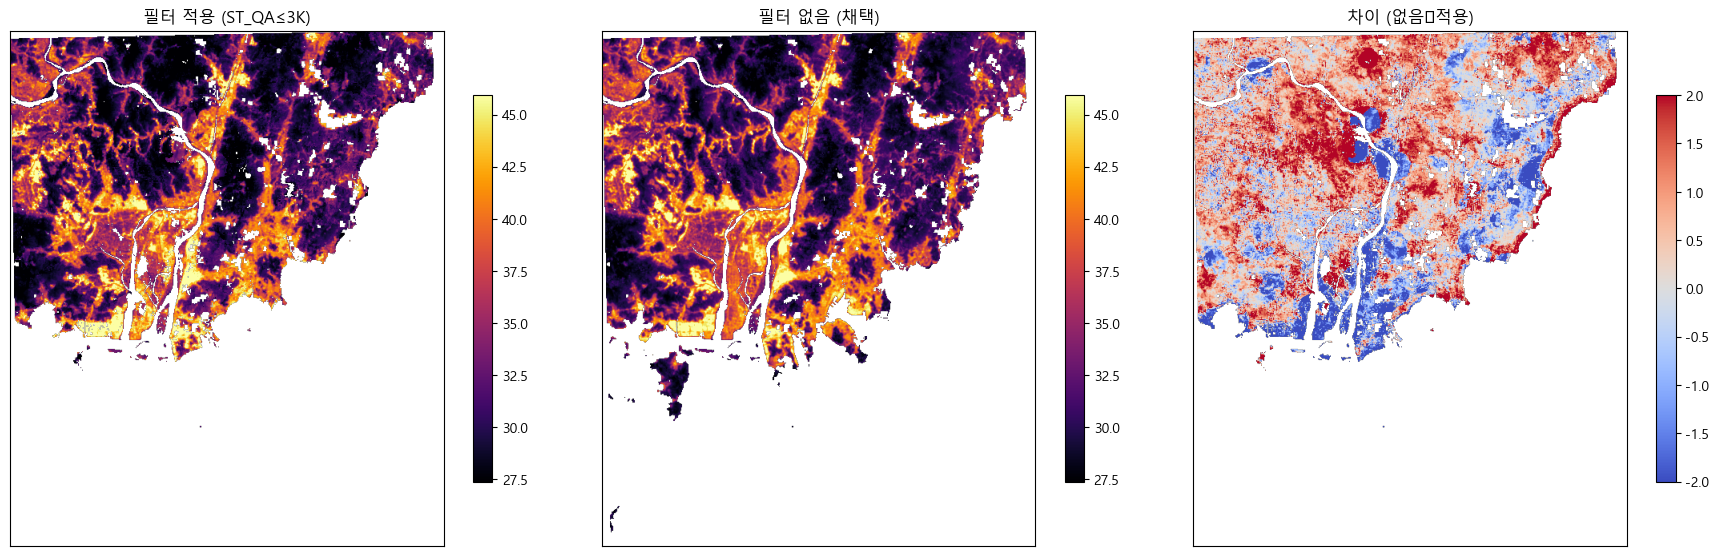

In [25]:
d = day_med - day_med_f
m = np.isfinite(d) & LAND
print(f"공통 {int(m.sum()):,} 셀")
print(f"  공간상관 r(필터 유·무)  {np.corrcoef(day_med_f[m], day_med[m])[0,1]:.4f}")
print(f"  차이 평균 {d[m].mean():+.3f} °C  표준편차 {d[m].std():.3f}")
print()
print("차이의 공간 편향 (|r| < 0.3 이면 안심)")
for nm, v in [("ST_QA>3K 비율", stqa_hi), ("수변거리", DIST_W),
              ("표고", ELEV), ("주간 nobs", day_nobs)]:
    mm = m & np.isfinite(v)
    print(f"  차이 ~ {nm:14s} r = {np.corrcoef(d[mm], v[mm])[0,1]:+.3f}")
print()
new_only = np.isfinite(day_med) & ~np.isfinite(day_med_f) & LAND
print(f"새로 채워진 셀 {int(new_only.sum()):,} ({new_only.sum()/N_LAND:.1%} of 육지)")
print(f"  그 셀의 nobs 중앙 {np.nanmedian(day_nobs[new_only]):.0f}회 "
      f"| ST_QA 중앙 {np.nanmedian(stqa_med[new_only]):.2f} K")

show([("필터 적용 (ST_QA≤3K)", day_med_f, "inferno",
       (np.nanpercentile(day_med[LAND], 2), np.nanpercentile(day_med[LAND], 98))),
      ("필터 없음 (채택)", day_med, "inferno",
       (np.nanpercentile(day_med[LAND], 2), np.nanpercentile(day_med[LAND], 98))),
      ("차이 (없음−적용)", np.where(m, d, np.nan), "coolwarm", (-2, 2))])

In [26]:
# 불확실도 요약 — 보고서용
print("Landsat 주간 LST 불확실도 (ST_QA)")
print(f"  개별 관측 중앙        {np.nanmedian(stqa_med[LAND]):.2f} K")
print(f"  3K 초과 관측 비율     {np.nanmedian(stqa_hi[LAND]):.1%}")
n_med = np.nanmedian(day_nobs[LAND])
print(f"  합성 관측 수 중앙     {n_med:.0f}회")
print(f"  → 랜덤 성분 저감 후   약 {np.nanmedian(stqa_med[LAND])/np.sqrt(n_med):.2f} K")
print()
print("ECOSTRESS 야간 장면 오프셋")
q1, q3 = np.percentile(b, [25, 75]); iqr = q3-q1
outl = np.sum((b < q1-1.5*iqr) | (b > q3+1.5*iqr))
print(f"  범위 {b.min():+.2f} ~ {b.max():+.2f} °C | IQR {q1:+.2f} ~ {q3:+.2f}")
print(f"  IQR 기준 이상치 {outl}건")
print(f"  시각 설명력 R² {r2_before:.3f} → 대부분 날씨·계절 변동")

Landsat 주간 LST 불확실도 (ST_QA)
  개별 관측 중앙        3.68 K
  3K 초과 관측 비율     71.7%
  합성 관측 수 중앙     41회
  → 랜덤 성분 저감 후   약 0.58 K

ECOSTRESS 야간 장면 오프셋
  범위 -6.21 ~ +8.33 °C | IQR -2.77 ~ +2.00
  IQR 기준 이상치 0건
  시각 설명력 R² 0.074 → 대부분 날씨·계절 변동



## 산출물

```
processed/
  busan_lst_day_median_100m.tif        LST_주간
  busan_lst_day_p90_100m.tif   busan_lst_day_nobs_100m.tif
  busan_day_stqa_median_100m.tif       불확실도
  busan_day_stqa_gt3K_frac_100m.tif
  busan_lst_night_median_100m.tif      LST_야간 (장면 정규화)
  busan_lst_night_p10_100m.tif  busan_lst_night_nobs_100m.tif
  busan_lst_night_anomaly_100m.tif  ★  LST_anomaly
  busan_lst_day_anomaly_100m.tif
  busan_land_100m.tif   busan_dist_water_100m.tif
  busan_in_boundary_100m.tif
  busan_lst_night_stack_100m.tif  + _index.csv   AWS 검증용
tables/
  part1_lst_hex_r10.parquet / .csv     분석 테이블 (조인 키 = hex_id)
  busan_hex_r10.gpkg   adm_dong_lut.csv   part1_meta.json
```

**조인 키는 `hex_id`** (H3 res 10). 파트 2·4는 100m 래스터를 만든 뒤:
```python
lon, lat = transform("EPSG:5186", "EPSG:4326", x_centers, y_centers)
hex_id   = [h3.latlng_to_cell(la, lo, 10) for la, lo in zip(lat, lon)]
df.groupby("hex_id").mean()
```